# ftir_40 — Seasonal paired quartz/TOR campaign design

## tl;dr

The Davis data confirm that statistical separation is easy and seasonal/systematic coverage
is the real design constraint. Historical Addis Fabs implies a MAC=6 versus MAC=10 EC gap of
**2.88–3.74 µg m⁻³** by season. Measured ETAD HIPS uncertainty is ~**0.29 µg m⁻³** after
MAC=10 conversion, and the five Adama quartz filters show only ~**0.10 µg m⁻³** SD between
TOR reflectance and transmittance EC. Under a deliberately conservative TOR error model,
12 paired days per season have >99% simulated 95%-confidence power even if only half the
nominal gap survives, although a stringent 5σ result at half signal is only ~40–50% likely.
The recommended campaign remains **36 primary pairs (13 Dry, 12 Belg, 11 Kiremt) plus six
seasonal field blanks and six collocated duplicates**, blocked across season and month.

## Context & Methods

Power resamples the observed Addis Fabs distribution within each canonical dry-owns-February
season. Each simulated paired difference combines the MAC gap with a conservative TOR error
model (10% of EC at MAC=6 + 0.3 µg m⁻³), measured ETAD HIPS uncertainty, and the Batch-54
TOR reflectance/transmittance spread. Both the nominal gap and a 50%-retained stress case are
reported. This is design simulation, not evidence that either MAC is correct.

### Key assumptions

- Canonical calendar: Dry Oct–Feb, Belg Mar–May, Kiremt Jun–Sep.
- Daily Teflon and quartz samples are collocated and share the same sampling interval.
- Batch, transport, face-velocity, and medium effects may halve the nominal signal; this is
  why the design optimizes coverage and QC rather than the smallest statistical n.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sys.path.insert(0, './scripts')
sys.path.insert(0, '../ftir_hips_chem/scripts')
from plotting import apply_default_style
from theory_test_suite import campaign_design_analysis, davis_root

apply_default_style()
ROOT = Path('.')
OUT = ROOT / 'output/tables/ftir40'
PLOTS = ROOT / 'output/plots/ftir40'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
print('Davis source root:', davis_root())

Davis source root: /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/Data/Davis Data


## Data

### Feasibility and data quality

The historical season table uses the 239 shipped Addis filters. The Adama Batch-54
feasibility input contains five quartz filters with both ECTR and ECTT results; it informs
protocol spread but is too small to estimate the full campaign variance on its own.

In [2]:
season_summary, power, allocation, qc = campaign_design_analysis()
display(season_summary.round(3))
display(allocation)
display(qc)

season_summary.to_csv(OUT / 'seasonal_effect_and_uncertainty.csv', index=False)
power.to_csv(OUT / 'seasonal_power_simulation.csv', index=False)
allocation.to_csv(OUT / 'recommended_allocation.csv', index=False)
qc.to_csv(OUT / 'quality_control_plan.csv', index=False)

,season,historical_filters,Fabs_median,Fabs_p25,Fabs_p75,expected_MAC6_minus_MAC10_ugm3,HIPS_sigma_ugm3,Adama_ECTR_minus_ECTT_sd_ugm3,paired_sigma_ugm3
0,Belg (Mar-May),61,47.110,40.565,53.430,3.141,0.29,0.101,0.307
1,Dry (Oct-Feb),105,43.176,36.992,47.957,2.878,0.29,0.101,0.307
2,Kiremt (Jun-Sep),73,56.133,49.553,64.279,3.742,0.29,0.101,0.307


,season,months,primary_pairs,field_blanks,collocated_duplicates,total_filters
0,Dry (Oct-Feb),"Oct, Nov, Dec, Jan, Feb",13,2,2,17
1,Belg (Mar-May),"Mar, Apr, May",12,2,2,16
2,Kiremt (Jun-Sep),"Jun, Jul, Aug, Sep",11,2,2,15


,measurement,role,n
0,paired Teflon HIPS + quartz TOR,primary endpoint,36
1,"field blanks, both media",season-specific contamination/blank correction,6
2,collocated duplicate pairs,sampling + analytical precision,6
3,TOR reflectance/transmittance split,protocol sensitivity retained from Batch 54,36


## Results

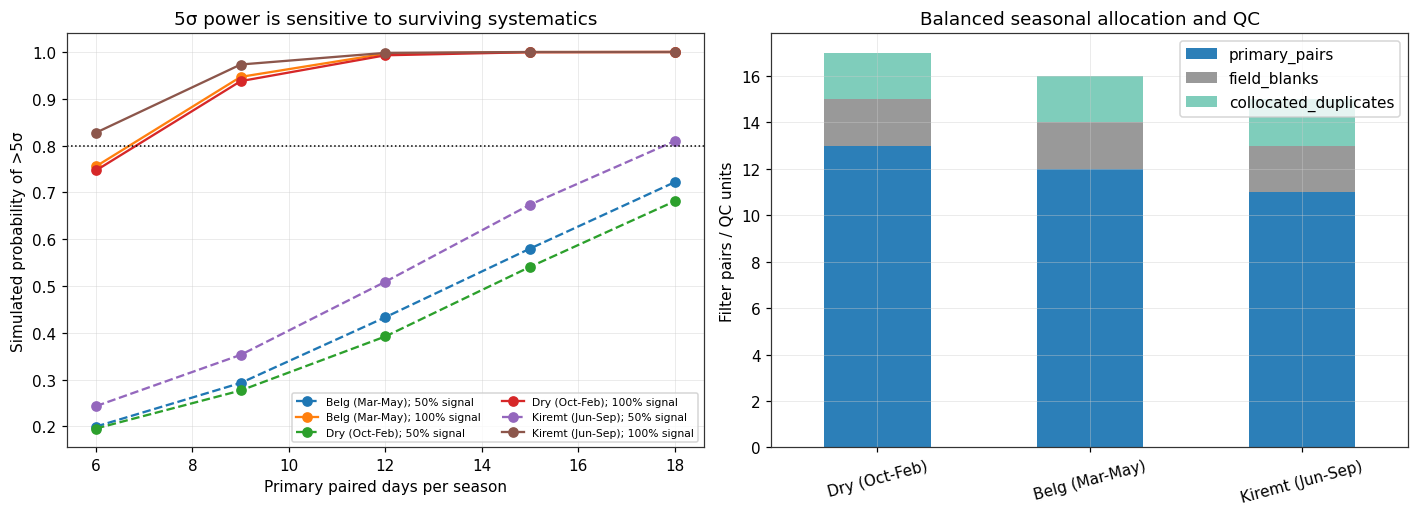

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for (season, retained), group in power.groupby(['season', 'effect_retained']):
    style = '-' if retained == 1 else '--'
    axes[0].plot(group['n_primary_pairs'], group['simulated_power_5sigma'],
                 marker='o', ls=style, label=f'{season}; {retained:.0%} signal')
axes[0].axhline(.8, color='black', ls=':', lw=1)
axes[0].set(xlabel='Primary paired days per season', ylabel='Simulated probability of >5σ',
            title='5σ power is sensitive to surviving systematics')
axes[0].legend(fontsize=7, ncol=2)

allocation.set_index('season')[['primary_pairs', 'field_blanks', 'collocated_duplicates']].plot.bar(
    stacked=True, ax=axes[1], color=['#2C7FB8', '#999999', '#7FCDBB'])
axes[1].set(xlabel='', ylabel='Filter pairs / QC units',
            title='Balanced seasonal allocation and QC')
axes[1].tick_params(axis='x', rotation=15)

fig.tight_layout()
fig.savefig(PLOTS / 'quartz_tor_campaign_design.png', bbox_inches='tight')
plt.show()

## Takeaways

- **Keep the 36-pair seasonal design.** The extra days are buying season/month coverage,
  robustness to missing samples, and interaction tests—not basic two-MAC significance.
- **Randomize analysis order within batches and balance media across batches.** Otherwise a
  batch drift can masquerade as a seasonal effect.
- **Retain both ECTR and ECTT plus raw HIPS R/T.** The campaign must adjudicate protocol and
  loading mechanisms, not only produce one EC column.
- **Pre-register the primary endpoint:** paired `TOR EC − Fabs/10`, with season×loading
  interactions and a declared MAC sensitivity. Do not choose MAC after viewing the paired
  results.
- **Stop condition:** if pilot blanks, duplicate CV, or quartz/Teflon flow mismatch exceeds
  the conservative design envelope, revise sampling hardware before completing all seasons.